#US bysykkel data

- data is from 2024
- Contact person is Christoffer Bakken Åkre (US)

In [43]:
import pandas as pd
from pathlib import Path
import os

## Load data fron raw_files

In [45]:
# Get the directory where this notebook is located
notebook_dir = Path(os.getcwd())

# Create relative path to raw_files
raw_files_dir = notebook_dir / 'trip_data' / 'raw_files'

# Load all parquet files
parquet_files = sorted(raw_files_dir.glob('*.parquet'))

print(f"Found {len(parquet_files)} parquet files in {raw_files_dir}")

# Load all files into a list of dataframes
dfs = []
for file in parquet_files:
    print(f"Loading {file.name}...")
    df = pd.read_parquet(file)
    dfs.append(df)

# Combine all dataframes
data = pd.concat(dfs, ignore_index=True)

data.head()

Found 9 parquet files in c:\Users\Minamsj\FOMOsim\policies\sjovik_sund\US_data\trip_data\raw_files
Loading 000000000000.parquet...
Loading 000000000001.parquet...
Loading 000000000001.parquet...
Loading 000000000002.parquet...
Loading 000000000002.parquet...
Loading 000000000003.parquet...
Loading 000000000004.parquet...
Loading 000000000003.parquet...
Loading 000000000004.parquet...
Loading 000000000005.parquet...
Loading 000000000005.parquet...
Loading 000000000006.parquet...
Loading 000000000006.parquet...
Loading 000000000007.parquet...
Loading 000000000008.parquet...
Loading 000000000007.parquet...
Loading 000000000008.parquet...


,vehicle_id,position_at,position_wkt,position_latitude,position_longitude,position_accuracy,trip_started_at,trip_ended_at,trip_id,trip_state,...,trip_end_dock_number,trip_end_dock_group_id,trip_end_dock_group_title,user_id,product_id,product_name,product_price,product_sales_channel,product_sales_locale,sale_from_value_code
0,4036,2024-03-22 05:51:00.756,b'\x01\x01\x00\x00\x00\xe0-\x90\xa0\xf8\xd1$@\...,63.4356,10.4101,719,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
1,4036,2024-03-22 05:51:16.061,b'\x01\x01\x00\x00\x00\xe0-\x90\xa0\xf8\xd1$@\...,63.4356,10.4101,553,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
2,4036,2024-03-22 05:51:30.793,b'\x01\x01\x00\x00\x00\xe4\x83\x9e\xcd\xaa\xcf...,63.4352,10.4056,79,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
3,4036,2024-03-22 05:51:45.773,b'\x01\x01\x00\x00\x00;\x01M\x84\r\xcf$@:\xb4\...,63.4355,10.4044,79,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False
4,4036,2024-03-22 05:51:53.128,b'\x01\x01\x00\x00\x00\xe6?\xa4\xdf\xbe\xce$@\...,63.4357,10.4038,74,2024-03-22 05:50:20.367,2024-03-22 05:53:01.113,60454069,completed,...,4.0,105.0,Trondheim S,6EBAB4B207B32AF49F5DC31E69BBF5A331E7C6FEF22A38...,1713,Sesongpass 2024,479.2,app,nb,False


In [ ]:
# Check for duplicates in the loaded data
print(f"Total rows: {len(data)}")
print(f"Unique rows: {data.drop_duplicates().shape[0]}")
print(f"\nData shape: {data.shape}")
print(f"\nData info:")
data.info()

Total rows: 5748944
Unique rows: 5747513

Data shape: (5748944, 24)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5748944 entries, 0 to 5748943
Data columns (total 24 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   vehicle_id                   int64         
 1   position_at                  datetime64[us]
 2   position_wkt                 object        
 3   position_latitude            float64       
 4   position_longitude           float64       
 5   position_accuracy            int64         
 6   trip_started_at              datetime64[us]
 7   trip_ended_at                datetime64[us]
 8   trip_id                      int64         
 9   trip_state                   object        
 10  trip_unlock_method           object        
 11  trip_start_dock_number       int64         
 12  trip_start_dock_group_id     int64         
 13  trip_start_dock_group_title  object        
 14  trip_end_dock_numb

## Data Dictionary

Description of fields in the US bysykkel dataset:

In [ ]:
# Create a data dictionary by examining the data
field_descriptions = {
    'vehicle_id': 'Unique identifier for the bike/scooter',
    'position_at': 'Timestamp of the position reading',
    'position_wkt': 'Well-Known Text representation of position',
    'position_latitude': 'Latitude coordinate of the vehicle',
    'position_longitude': 'Longitude coordinate of the vehicle',
    'position_accuracy': 'GPS accuracy of the position reading',
    'trip_started_at': 'Timestamp when the trip started',
    'trip_ended_at': 'Timestamp when the trip ended',
    'trip_id': 'Unique identifier for the trip',
    'trip_state': 'Current state of the trip (e.g., active, completed)',
    'trip_unlock_method': 'Method used to unlock the vehicle',
    'trip_start_dock_number': 'Dock number where trip started',
    'trip_start_dock_group_id': 'ID of the dock group/station where trip started',
    'trip_start_dock_group_title': 'Name of the dock group/station where trip started',
    'trip_end_dock_number': 'Dock number where trip ended',
    'trip_end_dock_group_id': 'ID of the dock group/station where trip ended',
    'trip_end_dock_group_title': 'Name of the dock group/station where trip ended',
    'user_id': 'Unique identifier for the user',
    'product_id': 'ID of the product/subscription type',
    'product_name': 'Name of the product/subscription type',
    'product_price': 'Price of the product',
    'product_sales_channel': 'Channel through which the product was sold',
    'product_sales_locale': 'Locale/language of the sale',
    'sale_from_value_code': 'Code indicating the source/type of sale'
}

# Display as a formatted table
import pandas as pd
field_df = pd.DataFrame([
    {'Field': field, 'Description': desc, 'Type': str(data[field].dtype), 
     'Non-Null': data[field].notna().sum(), 'Null': data[field].isna().sum()}
    for field, desc in field_descriptions.items()
])

print("Data Dictionary:")
print("="*100)
field_df

Data Dictionary:


,Field,Description,Type,Non-Null,Null
0,vehicle_id,Unique identifier for the bike/scooter,int64,5748944,0
1,position_at,Timestamp of the position reading,datetime64[us],5748944,0
2,position_wkt,Well-Known Text representation of position,object,5748944,0
3,position_latitude,Latitude coordinate of the vehicle,float64,5748944,0
4,position_longitude,Longitude coordinate of the vehicle,float64,5748944,0
5,position_accuracy,GPS accuracy of the position reading,int64,5748944,0
6,trip_started_at,Timestamp when the trip started,datetime64[us],5748944,0
7,trip_ended_at,Timestamp when the trip ended,datetime64[us],5748944,0
8,trip_id,Unique identifier for the trip,int64,5748944,0
9,trip_state,"Current state of the trip (e.g., active, compl...",object,5748944,0


## Full data profile to txt

In [ ]:
# 1. Define the output file
output_file = "full_data_profile.txt"

# 2. Capture all columns in the dataframe
all_fields = data.columns.tolist()

# Using utf-8 encoding to ensure all special characters are captured correctly
with open(output_file, "w", encoding='utf-8') as f:
    f.write("--- COMPLETE DATA PROFILE ---\n")
    f.write(f"Total Columns Processed: {len(all_fields)}\n")
    f.write("="*40 + "\n")

    for field in all_fields:
        f.write(f"\nCOLUMN: {field}\n")
        f.write(f"  Total Unique Values: {data[field].nunique()}\n")
        f.write(f"  All Unique Values & Counts:\n")
        
        # value_counts() defaults to descending order, showing most frequent first
        counts = data[field].value_counts()
        
        # We iterate directly over the Series items
        for val, count in counts.items():
            f.write(f"    - {val}: {count}\n")
        
        f.write("-" * 30 + "\n")

print(f"Done! All unique values for every field have been printed to {output_file}")

Done! All unique values for every field have been printed to full_data_profile.txt


# Trip pattern analysis


## Length of trip

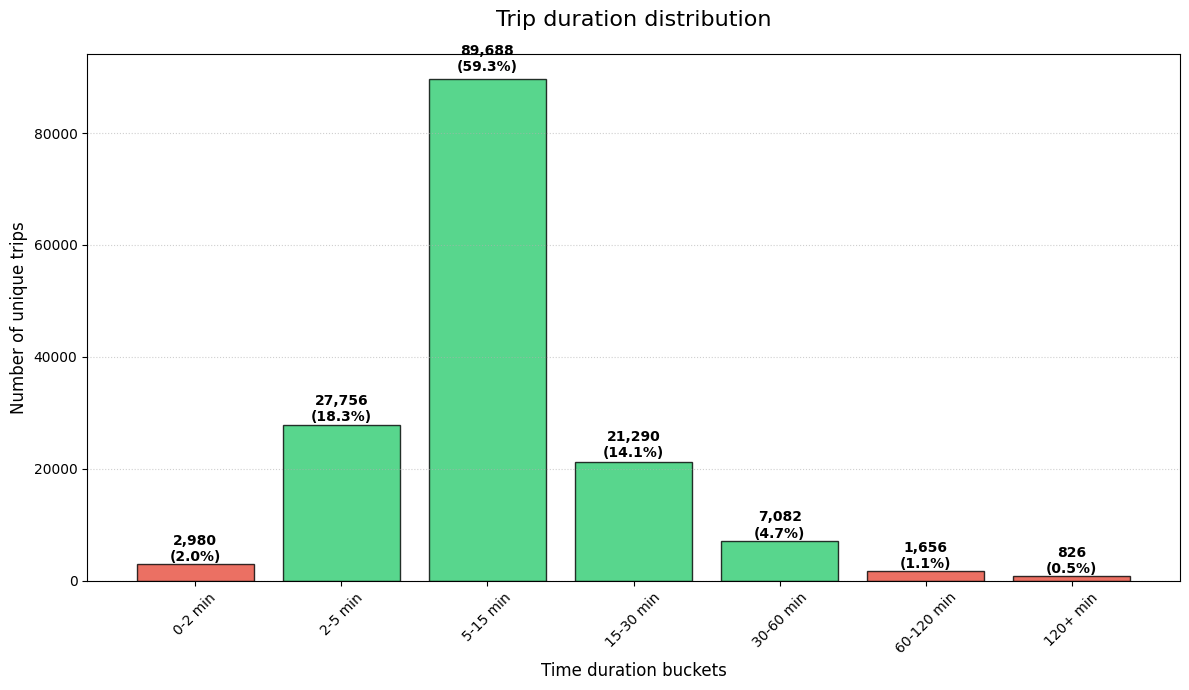

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Processing (Calculate unique trips and durations)
unique_trips = data.groupby('trip_id').first().reset_index()
trip_durations = (pd.to_datetime(unique_trips['trip_ended_at']) - 
                  pd.to_datetime(unique_trips['trip_started_at'])).dt.total_seconds() / 60

# 2. Define Granular Bins
bins = [0, 2, 5, 15, 30, 60, 120, float('inf')]
labels = ['0-2 min', '2-5 min', '5-15 min', '15-30 min', '30-60 min', '60-120 min', '120+ min']

# Cut data into buckets
duration_buckets = pd.cut(trip_durations, bins=bins, labels=labels)
counts = duration_buckets.value_counts().reindex(labels)

# 3. Define Color Logic
# Leftmost (index 0) and two rightmost (last two indices) = Red
# Everything else = Green
colors = []
for i in range(len(labels)):
    if i == 0 or i >= (len(labels) - 2):
        colors.append('#e74c3c') # Soft Red
    else:
        colors.append('#2ecc71') # Soft Green

# 4. Create the Visualization
plt.figure(figsize=(12, 7))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.8)

# Formatting
plt.title('Trip duration distribution', fontsize=16, pad=20)
plt.xlabel('Time duration buckets', fontsize=12)
plt.ylabel('Number of unique trips', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Add Data Labels (Counts and Percentages)
total_trips = len(trip_durations)
for bar in bars:
    height = bar.get_height()
    if not np.isnan(height):
        percentage = (height / total_trips) * 100
        plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
                 f'{int(height):,}\n({percentage:.1f}%)', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Show unique long trips (over 90 minutes)
unique_trips['trip_duration_minutes'] = trip_durations
long_trips = unique_trips[trip_durations > 90][['trip_id', 'trip_start_dock_group_title',
                                                 'trip_end_dock_group_title','trip_started_at', 
                                                 'trip_ended_at', 'trip_duration_minutes']]

print(f"\nLong trips (over 90 minutes): {len(long_trips)} unique trips")
print("="*100)
long_trips.head(30)


Long trips (over 90 minutes): 1301 unique trips


,trip_id,trip_start_dock_group_title,trip_end_dock_group_title,trip_started_at,trip_ended_at,trip_duration_minutes
82,60473464,Trondheim S,None,2024-03-23 08:21:32.963,2024-03-23 11:35:00.436,193.457883
108,60476841,Strandveikaia,Lade idrettsanlegg vest,2024-03-23 12:46:11.145,2024-03-23 14:40:29.853,114.311800
164,60480481,TMV-odden,Lilleby,2024-03-23 18:03:14.493,2024-03-23 20:17:00.990,133.774950
201,60484696,Strandveikaia,None,2024-03-24 10:07:06.287,2024-03-24 13:10:01.042,182.912583
216,60487257,Dokkparken,None,2024-03-24 12:53:17.244,2024-03-24 15:55:01.085,181.730683
550,60522250,Nordre gate,None,2024-03-27 07:40:57.513,2024-03-27 10:45:00.456,184.049050
585,60525208,Kong Øysteins veg,Kong Øysteins veg,2024-03-27 12:52:51.634,2024-03-27 14:38:31.659,105.667083
705,60539554,Nordre gate,Dalen hageby,2024-03-28 14:29:22.868,2024-03-28 16:30:47.439,121.409517
721,60541328,Studentersamfundet,Studentersamfundet,2024-03-28 16:28:48.949,2024-03-28 18:08:52.301,100.055867
771,60547711,TMV-odden,TMV-odden,2024-03-29 10:23:25.751,2024-03-29 13:03:18.620,159.881150
